In [9]:
import sys
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix, roc_auc_score
import random
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import json
sys.path.append('../')
from data_provider.data_loader import load_dataset

### Experiment Configuration

In [ ]:
# Data parameters
DATA_FOLDER = '../data/'
DATASET_NAME = 'experiment3' # Change to dataset you wish to train on

# Processing parameters
TEST_SIZE = 0.2
VAL_SIZE = 0.1
RANDOM_SEED = 2026 # Random seed for reproducibility
MAX_FEATURES = 5000 # Limit the number of features for TF-IDF Vectorization

# Model Hyperparameters
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 0.001

# Reproducibility
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)


#### Load Dataset

In [11]:
df = load_dataset(DATA_FOLDER, DATASET_NAME)

# Check the column names to ensure features and labels are loaded correctly
if isinstance(df, dict):
    print(df['test'].head())
else:
    print(df.head())

                                                text  label       source  \
0  Comments\nThe U.S. bombings thatended World Wa...      0  Human_story   
1  ## The Unseen Scars: The Enduring Human Toll o...      1   gemma-2-9b   
2  \n\nTitle: The Atomic Aftermath: The U.S. Bomb...      1   mistral-7B   
3  Human Toll of Nuclear Testing: Unraveling the ...      1   qwen-2-72B   
4   The Ghostly Whispers of Trinity The Enduring ...      1     llama-8B   

                              prompt  
0  The Human Toll of Nuclear Testing  
1  The Human Toll of Nuclear Testing  
2  The Human Toll of Nuclear Testing  
3  The Human Toll of Nuclear Testing  
4  The Human Toll of Nuclear Testing  


#### Split dataset into training, validation, and test sets

In [12]:
# Dataset is not randomly ordered, so we will shuffle it to ensure a representative split between training and testing sets

if isinstance(df, dict):
    train_val_df = df['train']
    test_df = df['test']
else:
    train_val_df, test_df = train_test_split(
        df,
        test_size=TEST_SIZE,
        random_state=RANDOM_SEED,
        stratify=df['label'],
        shuffle=True
    )

train_df, val_df = train_test_split(
    train_val_df,
    test_size=(VAL_SIZE / (1.0 - TEST_SIZE)),
    random_state=RANDOM_SEED,
    stratify=train_val_df['label'],
    shuffle=True
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f'Train set size: {len(train_df)}')
print(f'Validation set size: {len(val_df)}')
print(f'Test set size: {len(test_df)}')

Train set size: 438698
Validation set size: 62672
Test set size: 51097


#### Vectorize text data using TF-IDF

In [13]:
vectorizer = TfidfVectorizer(max_features=MAX_FEATURES)

X_train = vectorizer.fit_transform(train_df['text']).toarray()
X_val = vectorizer.transform(val_df['text']).toarray()
X_test = vectorizer.transform(test_df['text']).toarray()

y_train = train_df['label'].values
y_val = val_df['label'].values
y_test = test_df['label'].values

#### Logistic Regression Model

In [14]:
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1)
    
    def forward(self, x):
        return self.linear(x)

#### Training Loop for Logistic Regression Model

In [15]:
def run_logistic_regression(X_train, y_train, X_val, y_val, X_test, y_test):
    model = LogisticRegressionModel(X_train.shape[1])
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32).reshape(-1, 1)

    num_epochs = EPOCHS
    batch_size = BATCH_SIZE

    for epoch in range(num_epochs):
        model.train()
        for i in tqdm(range(0, len(X_train_tensor), batch_size)):
            X_batch = X_train_tensor[i:i+batch_size]
            y_batch = y_train_tensor[i:i+batch_size]

            logits = model.forward(X_batch)
            loss = criterion(logits, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            model.eval()
            with torch.no_grad():
                val_logits = model.forward(X_val_tensor)
                val_loss = criterion(val_logits, y_val_tensor)

                val_probabilities = torch.sigmoid(val_logits)
                val_predicted_labels = (val_probabilities >= 0.5).float()
                val_correct = (val_predicted_labels == y_val_tensor).sum()
                val_accuracy = val_correct / len(y_val_tensor)

        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {loss.item()}, Validation Loss: {val_loss.item()}, Validation Accuracy: {val_accuracy.item()}')

    model.eval()
    with torch.no_grad():
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
        y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)
        logits = model.forward(X_test_tensor)
        probabilities = torch.sigmoid(logits)
        predicted_labels = (probabilities >= 0.5).float()

        correct = (predicted_labels == y_test_tensor).sum()
        accuracy = correct / len(y_test_tensor)
        print(f'Test Accuracy: {accuracy.item()}')

        y_true = y_test_tensor.flatten().numpy()
        y_pred = predicted_labels.flatten().numpy()
        y_scores = probabilities.flatten().numpy()
        test_roc_auc = roc_auc_score(y_true, y_scores)
        print(classification_report(y_true, y_pred, target_names=['Human', 'AI']))
        print(f'Test ROC-AUC: {test_roc_auc:.4f}')

        cm = confusion_matrix(y_true, y_pred)
        confusion_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Human', 'AI']).plot(cmap='Blues')
        plt.title('Logistic Regression Confusion Matrix')
        plt.show()

        from pathlib import Path
        import json

        results_dir = Path('../results') / f'logistic_regression__{DATASET_NAME}__max_features_{MAX_FEATURES}'
        results_dir.mkdir(parents=True, exist_ok=True)

        report_dict = classification_report(y_true, y_pred, target_names=['Human', 'AI'], output_dict=True)
        pd.DataFrame(cm, index=['Human', 'AI'], columns=['Predicted Human', 'Predicted AI']).to_csv(results_dir / 'confusion_matrix.csv')
        confusion_display.figure_.savefig(results_dir / 'confusion_matrix.png', bbox_inches='tight')

        logistic_metrics = {
            'dataset_name': DATASET_NAME,
            'test_accuracy': float(accuracy.item()),
            'test_roc_auc': float(test_roc_auc),
            'max_features': MAX_FEATURES,
            'batch_size': BATCH_SIZE,
            'epochs': EPOCHS,
            'learning_rate': LEARNING_RATE,
        }

        with (results_dir / 'metrics.json').open('w', encoding='utf-8') as metrics_file:
            json.dump(logistic_metrics, metrics_file, indent=2)

        with (results_dir / 'classification_report.json').open('w', encoding='utf-8') as report_file:
            json.dump(report_dict, report_file, indent=2)

        if DATASET_NAME == 'experiment3':
            source_results = []

            for source_column, source_subset in test_df.groupby('source'):
                source_texts = source_subset['text'].astype(str).tolist()
                source_features = vectorizer.transform(source_texts).toarray()
                source_tensor = torch.tensor(source_features, dtype=torch.float32)
                source_logits = model.forward(source_tensor)
                source_probabilities = torch.sigmoid(source_logits).squeeze(1).numpy()
                source_predictions = (source_probabilities >= 0.5).astype(int)

                source_results.append({
                    'source_model': source_column,
                    'samples': len(source_texts),
                    'detected_as_ai_rate': float(source_predictions.mean()),
                })

            source_results_df = pd.DataFrame(source_results)
            source_results_df.to_csv(results_dir / 'source_detection_rates.csv', index=False)

            print('Per-source detection rates on multi_model_detection.csv:')
            print(source_results_df)

        print(f'Saved logistic regression results to {results_dir}')

    return model


def predict_custom_texts(model, vectorizer, texts):
    if isinstance(texts, str):
        texts = [texts]

    features = vectorizer.transform(texts).toarray()
    feature_tensor = torch.tensor(features, dtype=torch.float32)

    model.eval()
    with torch.no_grad():
        probabilities = torch.sigmoid(model(feature_tensor)).squeeze(1).numpy()

    predictions = (probabilities >= 0.5).astype(int)
    results = pd.DataFrame(
        {
            'text': texts,
            'predicted_label': ['AI' if pred == 1 else 'Human' for pred in predictions],
            'ai_probability': probabilities,
        }
    )
    print(results)
    return results



#### Train our Logistic Regression model

100%|██████████| 3428/3428 [00:27<00:00, 124.36it/s]


Epoch 1/10, Train Loss: 0.1471990942955017, Validation Loss: 0.11546400934457779, Validation Accuracy: 0.9796559810638428


100%|██████████| 3428/3428 [00:24<00:00, 140.56it/s]


Epoch 2/10, Train Loss: 0.09206301718950272, Validation Loss: 0.06459090858697891, Validation Accuracy: 0.9869958162307739


100%|██████████| 3428/3428 [00:24<00:00, 141.58it/s]


...

Epoch 8/10, Train Loss: 0.01874302513897419, Validation Loss: 0.025401875376701355, Validation Accuracy: 0.9936654567718506


100%|██████████| 3428/3428 [00:24<00:00, 137.20it/s]


Epoch 9/10, Train Loss: 0.015370710752904415, Validation Loss: 0.023819128051400185, Validation Accuracy: 0.993984580039978


100%|██████████| 3428/3428 [00:24<00:00, 140.67it/s]


Epoch 10/10, Train Loss: 0.012878653593361378, Validation Loss: 0.022512735798954964, Validation Accuracy: 0.9943037033081055
Test Accuracy: 0.9083899259567261
              precision    recall  f1-score   support

       Human       0.73      0.57      0.64      7235
          AI       0.93      0.97      0.95     43862

    accuracy                           0.91     51097
   macro avg       0.83      0.77      0.79     51097
weighted avg       0.90      0.91      0.90     51097

Test ROC-AUC: 0.9437


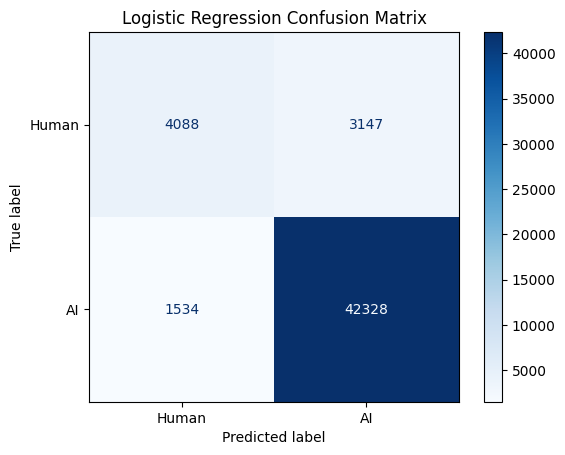

Per-source detection rates on multi_model_detection.csv:
                        source_model  samples  detected_as_ai_rate
0                            GPT_4-o     7307             0.961817
1                        Human_story     7235             0.434969
2  accounts/yi-01-ai/models/yi-large     7319             0.997267
3                         gemma-2-9b     7310             0.987278
4                           llama-8B     7304             0.920591
5                         mistral-7B     7308             0.988779
6                         qwen-2-72B     7314             0.934372
Saved logistic regression results to ../results/logistic_regression__experiment3__max_features_5000


In [16]:
trained_lr_model = run_logistic_regression(X_train, y_train, X_val, y_val, X_test, y_test)

#### Test Logistic Regression with Custom Inputs

In [17]:
custom_texts = [
    "This essay argues that social media can improve civic participation when paired with strong moderation policies.",
    "In conclusion, the provided evidence clearly demonstrates a multifaceted and highly structured perspective on the topic.",
    "This isn't working very well, as it seems to just be predicting AI for longer messages and Human for shorter messages. At least it's with a lower probability.",
]

predict_custom_texts(trained_lr_model, vectorizer, custom_texts)


                                                text predicted_label  \
0  This essay argues that social media can improv...              AI   
1  In conclusion, the provided evidence clearly d...              AI   
2  This isn't working very well, as it seems to j...              AI   

   ai_probability  
0        0.999995  
1        0.995698  
2        0.625250  


,text,predicted_label,ai_probability
0,This essay argues that social media can improv...,AI,0.999995
1,"In conclusion, the provided evidence clearly d...",AI,0.995698
2,"This isn't working very well, as it seems to j...",AI,0.625250


#### Save Logistic Regression Artifacts

In [18]:
from pathlib import Path
import json
import joblib

SAVE_DIR = Path('../artifacts/logistic_regression')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

torch.save(trained_lr_model.state_dict(), SAVE_DIR / 'weights.pt')
joblib.dump(vectorizer, SAVE_DIR / 'vectorizer.joblib')

logistic_config = {
    'dataset_name': DATASET_NAME,
    'test_size': TEST_SIZE,
    'val_size': VAL_SIZE,
    'random_seed': RANDOM_SEED,
    'max_features': MAX_FEATURES,
    'batch_size': BATCH_SIZE,
    'epochs': EPOCHS,
    'learning_rate': LEARNING_RATE,
    'input_dim': int(X_train.shape[1]),
}

with (SAVE_DIR / 'config.json').open('w', encoding='utf-8') as config_file:
    json.dump(logistic_config, config_file, indent=2)

print(f'Saved logistic regression artifacts to {SAVE_DIR}')


Saved logistic regression artifacts to ../artifacts/logistic_regression


#### Reload Logistic Regression Artifacts

In [19]:
from pathlib import Path
import joblib

RELOAD_DIR = Path('../artifacts/logistic_regression')

reloaded_vectorizer = joblib.load(RELOAD_DIR / 'vectorizer.joblib')
reloaded_lr_model = LogisticRegressionModel(X_train.shape[1])
reloaded_lr_model.load_state_dict(torch.load(RELOAD_DIR / 'weights.pt', map_location='cpu'))
reloaded_lr_model.eval()

print('Reloaded logistic regression artifacts.')


Reloaded logistic regression artifacts.
